In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
l=['name','online_order','book_table','rate','votes','location','rest_type','dish_liked','cuisines','approx_cost(for two people)','listed_in(type)','listed_in(city)']

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\zomato.csv")[l]

In [3]:
df.head()
df.sample()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
48829,Head's Or Tail's,No,Yes,4.0 /5,140,Wilson Garden,Bar,Beer,"Finger Food, North Indian, Chinese","1,000",Drinks & nightlife,Residency Road


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         51717 non-null  str  
 1   online_order                 51717 non-null  str  
 2   book_table                   51717 non-null  str  
 3   rate                         43942 non-null  str  
 4   votes                        51717 non-null  int64
 5   location                     51696 non-null  str  
 6   rest_type                    51490 non-null  str  
 7   dish_liked                   23639 non-null  str  
 8   cuisines                     51672 non-null  str  
 9   approx_cost(for two people)  51371 non-null  str  
 10  listed_in(type)              51717 non-null  str  
 11  listed_in(city)              51717 non-null  str  
dtypes: int64(1), str(11)
memory usage: 4.7 MB


### Data Cleaning

In [27]:
df.rename(columns={'approx_cost(for two people)':'cost_of_2'},inplace=True)

In [5]:
df['online_order'] = df['online_order'].str.replace('Yes', '1').replace('No', '0').astype('int8')

In [6]:
df['book_table'] = df['book_table'].str.replace('Yes', '1').replace('No', '0').astype('int8')

In [7]:
df['rate'].isnull().sum() #df['rate'].isnull().sum()
df['rate'] = df['rate'].ffill()
df['rate'] = df['rate'].str.replace('/5','')
df['rate'] = df['rate'].replace('NEW','0')
df['rate'] = df['rate'].replace('-','0')
df['rate'] = df['rate'].astype('f')

In [8]:
df['online_order']
df['book_table']
df['rate']

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    3.6
51714    3.6
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float32

In [42]:
df['cost_of_2'].isnull().sum() #np.int64(346)
# df.dropna(axis=0)['cost_of_2'].isnull().sum()
df.dropna(axis=0, inplace=True)
df['cost_of_2'] = df['cost_of_2'].str.replace(',','')
df['cost_of_2'] = df['cost_of_2'].astype('int16')

### Data Analysis and Visualization

In [49]:
on_of = df.groupby(['online_order', 'book_table'])

([<matplotlib.axis.XTick at 0x25ab045afd0>,
 [Text(0, 0, 'neither online or dinin'),
  Text(1, 0, 'dinin'),
  Text(2, 0, 'online order'),
  Text(3, 0, 'both online and offline')])

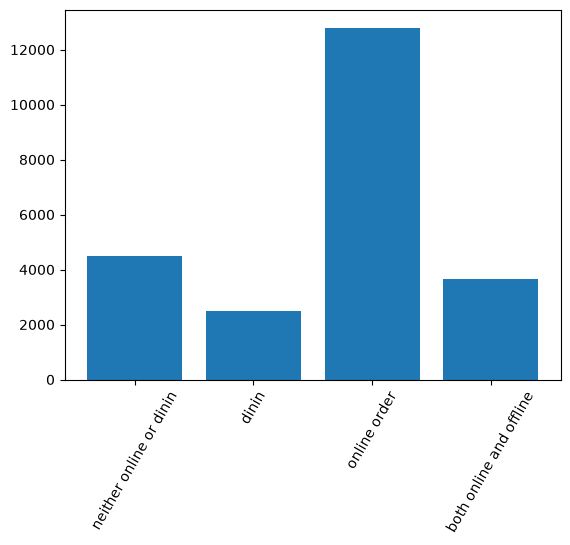

In [50]:
on_of_size = on_of.size()
x = [i[0] for i in list(enumerate(on_of_size.index))]

plt.bar(x, on_of_size.values)
plt.xticks([0,1,2,3], ['neither online or dinin', 'dinin', 'online order', 'both online and offline'], rotation= 60)

In [51]:
nod = on_of.get_group((0,0))['rate'].sort_values()
din_in = on_of.get_group((0,1))['rate'].sort_values()
on_ord = on_of.get_group((1,0))['rate'].sort_values()
both = on_of.get_group((1,1))['rate'].sort_values()

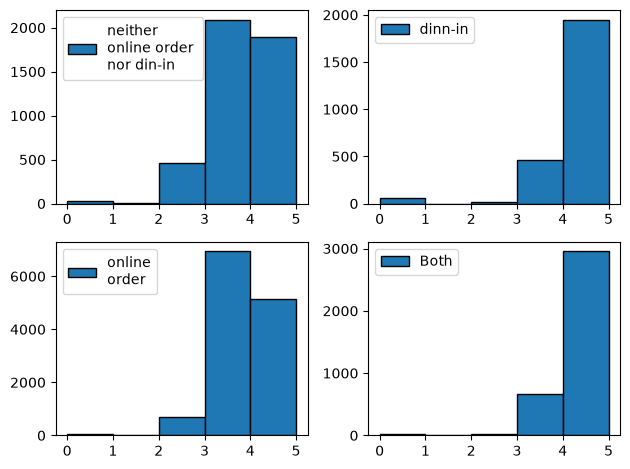

In [52]:
bins = [0,1,2,3,4,5]

plt.subplot(2,2,1)
plt.hist(nod, bins = bins, edgecolor = 'black', label='neither \nonline order \nnor din-in')
plt.legend(loc = "upper left")

plt.subplot(2,2,2)
plt.hist(din_in, bins=bins, edgecolor = 'black', label= 'dinn-in')
plt.legend(loc = "upper left")

plt.subplot(2,2,3)
plt.hist(on_ord, bins=bins, edgecolor = 'black', label= 'online\norder')
plt.legend(loc = "upper left")

plt.subplot(2,2,4)
plt.hist(both, bins=bins, edgecolor = 'black', label= 'Both')
plt.legend(loc = "upper left")

plt.tight_layout()

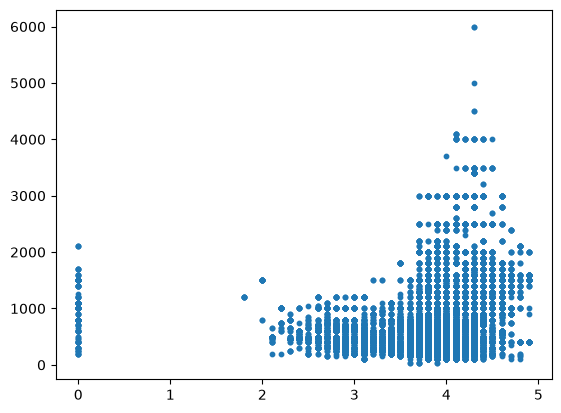

In [59]:
x = df['rate']
y = df['cost_of_2']

plt.scatter(x,y,s =10)

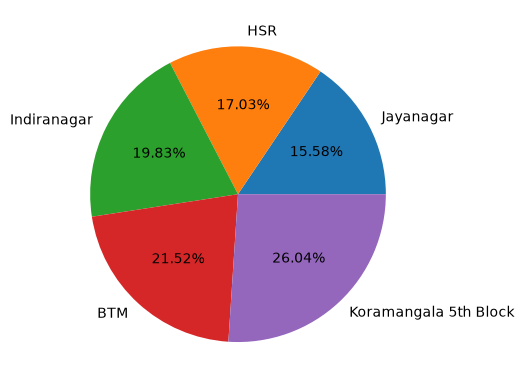

In [ ]:
lic = df.groupby('location')
x = lic['name'].size().sort_values().tail()
plt.pie(x=x,labels=x.index,autopct='%.2f%%')